# Week 3 & 4 Project
## Task 1 – Data Loading, Merging & Deep Exploration

### Objective
The objective of this task is to perform comprehensive exploratory data analysis (EDA) on the Superstore Sales dataset. This includes:

- Loading and inspecting the dataset
- Cleaning the data
- Extracting useful time-based features
- Aggregating sales into weekly and monthly levels
- Answering business-related questions using data analysis
- Visualizing trends and insights

## Step 1: Import Required Libraries

We begin by importing the Python libraries required for data manipulation, visualization, and analysis.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

## Step 2: Load the Dataset

The Superstore Sales dataset is loaded using Pandas. The **Order Date** and **Ship Date** columns are directly parsed into datetime format to enable time-based analysis.

In [3]:
df = pd.read_csv(
    "train.csv",
    parse_dates=["Order Date","Ship Date"]
)

print("Shape:",df.shape)
display(df.head())

Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Step 3: Understand the Dataset

Before performing any analysis, it is important to understand:

- Number of rows and columns
- Data types
- Missing values
- Numerical summaries

In [4]:
df.info()

display(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


## Step 4: Check for Missing Values

Missing values can affect the quality of analysis and machine learning models. We identify missing values in each column.

In [5]:
missing = pd.DataFrame({
    "Missing Count":df.isnull().sum(),
    "Percentage":(df.isnull().mean()*100).round(2)
})

display(missing)

,Missing Count,Percentage
Row ID,0,0.00
Order ID,0,0.00
Order Date,0,0.00
Ship Date,0,0.00
Ship Mode,0,0.00
Customer ID,0,0.00
Customer Name,0,0.00
Segment,0,0.00
Country,0,0.00
City,0,0.00


## Step 5: Check for Duplicate Records

Duplicate rows can lead to incorrect analysis. We identify and remove duplicates if present.

In [6]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:",duplicates)

if duplicates>0:
    df=df.drop_duplicates()
    print("Duplicates Removed Successfully")

Duplicate Rows: 0


## Step 6: Verify Data Types

We verify that each column has the appropriate data type before proceeding with feature engineering.

In [7]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

# Feature Engineering

Time-based features often reveal valuable business insights. We extract multiple features from the Order Date.

## Step 7: Extract Time Features

The following features are extracted:

- Year
- Month
- Month Name
- Week Number
- Day of Week
- Quarter
- Season

In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)
df["Year"]=df["Order Date"].dt.year
df["Month"]=df["Order Date"].dt.month
df["Month Name"]=df["Order Date"].dt.month_name()
df["Week Number"]=df["Order Date"].dt.isocalendar().week
df["Day of Week"]=df["Order Date"].dt.day_name()
df["Quarter"]=df["Order Date"].dt.quarter

## Step 8: Create Season Feature

The month values are grouped into four seasons for seasonal sales analysis.

In [9]:
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"

df["Season"]=df["Month"].apply(get_season)

display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


## Step 9: Calculate Shipping Duration

Shipping duration is calculated as the number of days between the Order Date and Ship Date.

In [10]:
df["Shipping Days"]=(df["Ship Date"]-df["Order Date"]).dt.days

display(df[["Order Date","Ship Date","Shipping Days"]].head())

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


# Sales Aggregation

Different forecasting models require different time granularities. Therefore, weekly and monthly sales are calculated separately.

## Weekly Sales

In [11]:
weekly_sales=(df.set_index("Order Date").resample("W")["Sales"].sum().reset_index())

display(weekly_sales.head())

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


## Monthly Sales

In [12]:
monthly_sales=(df.set_index("Order Date").resample("M")["Sales"].sum().reset_index())

display(monthly_sales.head())

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


# Business Question 1

## Which product category generates the highest total revenue?

We calculate the total sales for each product category and visualize the results.

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

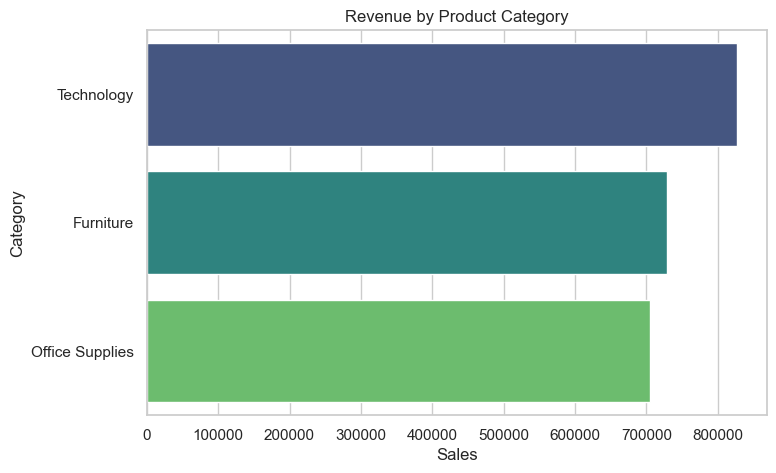

In [13]:
category_sales=df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

display(category_sales)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index,
    palette="viridis"
)

plt.title("Revenue by Product Category")
plt.xlabel("Sales")
plt.ylabel("Category")

plt.show()

### Interpretation

The visualization shows the contribution of each product category toward total revenue. Technology generates the highest revenue and contributes the most to the company's overall revenue.

# Business Question 2

## Which region has the most consistent sales growth over four years?

Annual sales are calculated for each region. A line chart is used to observe trends, while the standard deviation of yearly sales is used as a measure of consistency.

,Region,Year,Sales
0,Central,2015,102920.5206
1,Central,2016,102425.1724
2,Central,2017,145673.8800
3,Central,2018,141627.3402
4,East,2015,127652.8190
5,East,2016,153225.1830
6,East,2017,178511.5380
7,East,2018,210129.1860
8,South,2015,103374.9055
9,South,2016,70076.0825


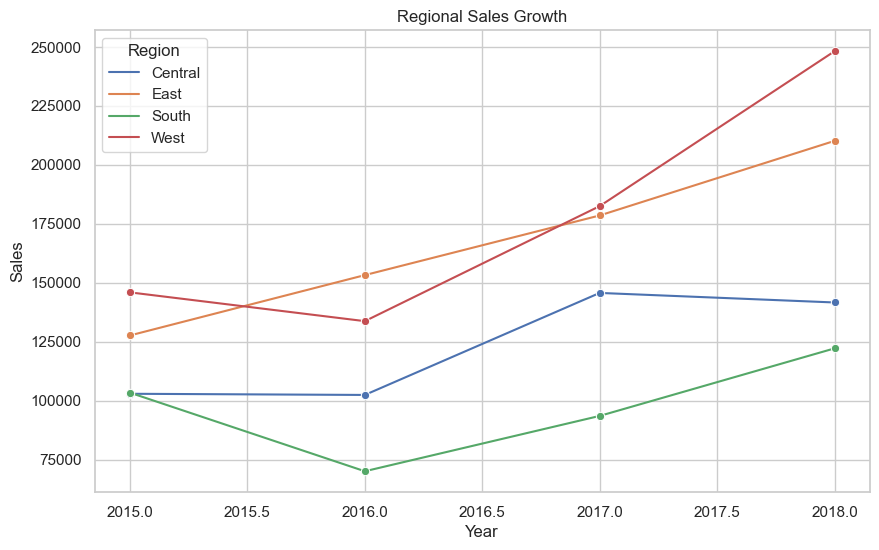

Region
South      21683.024937
Central    23716.991355
East       35260.987867
West       51410.399288
Name: Sales, dtype: float64

Most Consistent Region: South


In [14]:
region_year=df.groupby(["Region","Year"])["Sales"].sum().reset_index()

display(region_year)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Regional Sales Growth")

plt.show()

consistency=region_year.groupby("Region")["Sales"].std().sort_values()

display(consistency)

print("Most Consistent Region:",consistency.index[0])

### Interpretation

A lower standard deviation indicates that yearly sales fluctuate less over time. Therefore, the region with the smallest standard deviation demonstrates the most consistent sales growth.

# Business Question 3

## What is the average shipping time?

The shipping duration is calculated overall and separately for each region.

Average Shipping Days
3.96


Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64

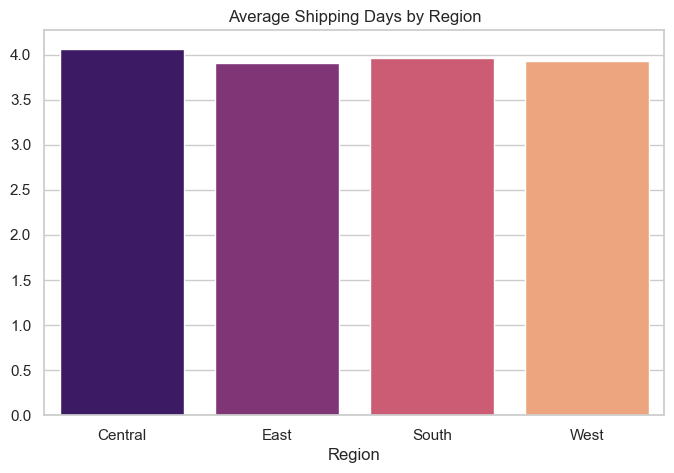

In [15]:
print("Average Shipping Days")

print(df["Shipping Days"].mean().round(2))

shipping_region=df.groupby("Region")["Shipping Days"].mean()

display(shipping_region)

plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values,
    palette="magma"
)

plt.title("Average Shipping Days by Region")

plt.show()

### Interpretation

The average shipping duration indicates the efficiency of the logistics process. Comparing regions helps identify areas with faster or slower delivery performance.The average shipping time varies from region to region


# Business Question 4

## Are there months that consistently spike accross all years ?

Monthly sales are analyzed across different years to identify recurring seasonal patterns.

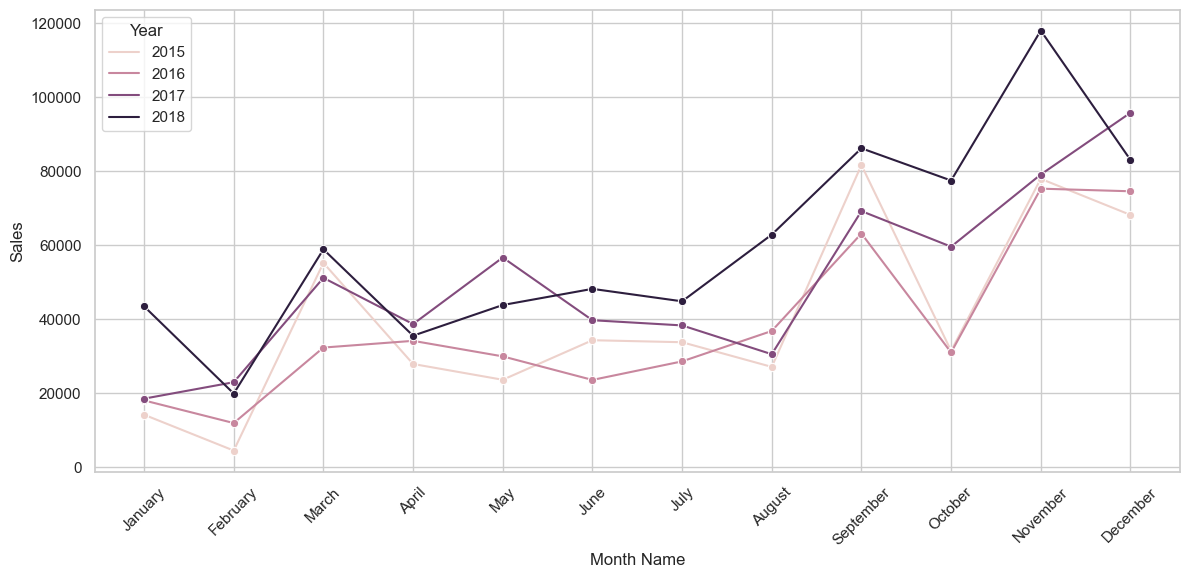

In [16]:
seasonality=df.groupby(["Year","Month Name"])["Sales"].sum().reset_index()

month_order=[
"January","February","March","April",
"May","June","July","August",
"September","October","November","December"
]

seasonality["Month Name"]=pd.Categorical(
seasonality["Month Name"],
categories=month_order,
ordered=True
)

seasonality=seasonality.sort_values(["Year","Month Name"])

plt.figure(figsize=(14,6))

sns.lineplot(
data=seasonality,
x="Month Name",
y="Sales",
hue="Year",
marker="o"
)

plt.xticks(rotation=45)

plt.show()

## Heatmap of Monthly Sales

A heatmap provides a compact visual representation of seasonal sales patterns across different years.

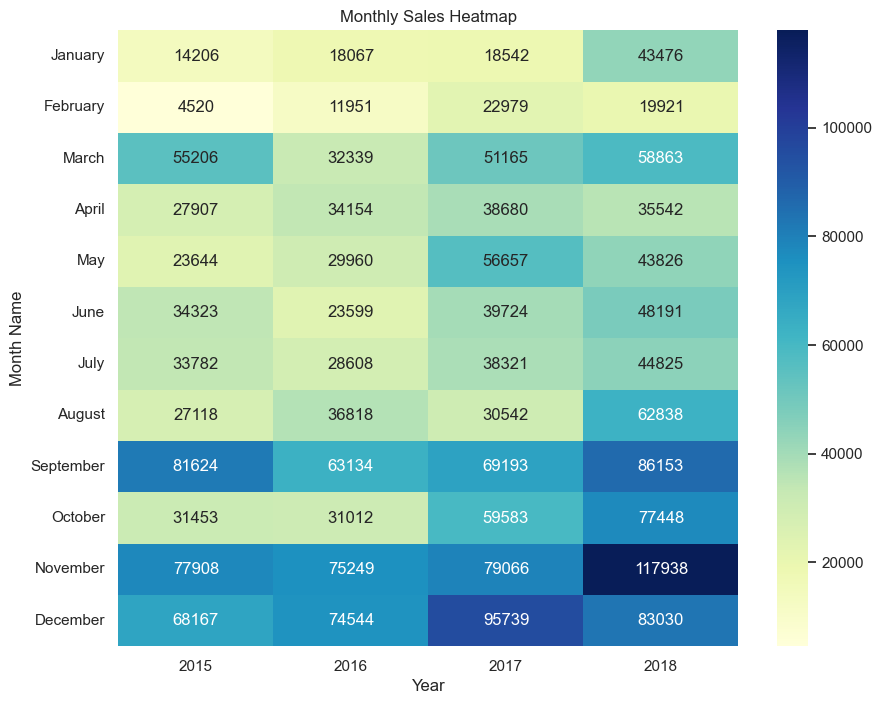

In [17]:
pivot=df.pivot_table(
values="Sales",
index="Month Name",
columns="Year",
aggfunc="sum"
)

pivot=pivot.reindex(month_order)

plt.figure(figsize=(10,8))

sns.heatmap(
pivot,
annot=True,
fmt=".0f",
cmap="YlGnBu"
)

plt.title("Monthly Sales Heatmap")

plt.show()

# Task 2 – Time Series Analysis & Decomposition

## Objective

The objective of this task is to analyze the monthly sales time series by:

- Visualizing the overall sales trend
- Decomposing the series into Trend, Seasonal, and Residual components
- Identifying long-term patterns and seasonality
- Testing stationarity using the Augmented Dickey-Fuller (ADF) Test
- Applying differencing if necessary

## Step 1: Import Required Libraries

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

## Step 2: Prepare Monthly Time Series

The monthly sales data created in Task 1 is converted into a time series using **Order Date** as the index.

In [19]:
monthly_ts = monthly_sales.copy()

monthly_ts["Order Date"] = pd.to_datetime(monthly_ts["Order Date"])

monthly_ts = monthly_ts.set_index("Order Date")

monthly_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


## Step 3: Plot Monthly Sales Trend

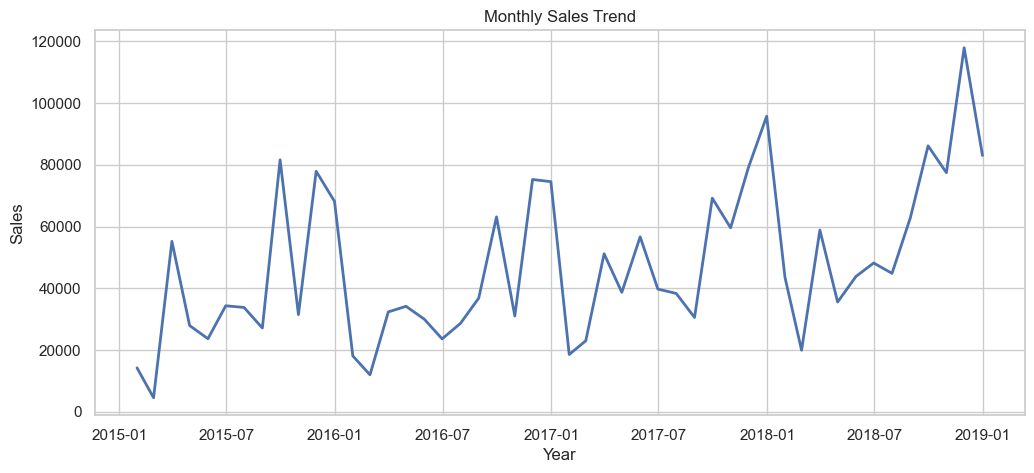

<Figure size 640x480 with 0 Axes>

In [20]:
plt.figure(figsize=(12,5))

plt.plot(monthly_ts.index, monthly_ts["Sales"], linewidth=2)

plt.title("Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()
plt.savefig("charts/monthly_trend.png", dpi=300, bbox_inches="tight")

## Step 4: Time Series Decomposition

The monthly sales are decomposed into:

- Trend
- Seasonal
- Residual (Noise)

This helps understand the underlying behavior of the time series.

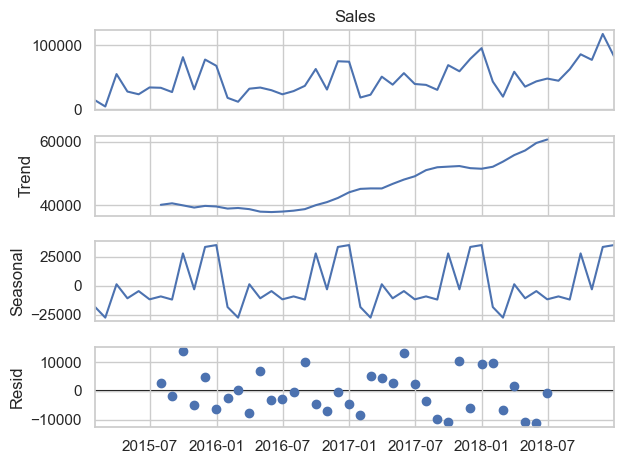

<Figure size 640x480 with 0 Axes>

In [70]:
decomposition = seasonal_decompose(
    monthly_ts["Sales"],
    model="additive",
    period=12
)

decomposition.plot()

plt.show()
plt.savefig("charts\decomposition.png", dpi=300, bbox_inches="tight")

### Observations

- The trend component shows the long-term direction of sales.
- The seasonal component highlights recurring yearly patterns.
- The residual component represents random fluctuations not explained by trend or seasonality.
- Large spikes in the residual plot indicate unusual sales activity.

## Step 5: Augmented Dickey-Fuller (ADF) Test

A time series is **stationary** if its statistical properties (mean and variance) remain approximately constant over time.

The ADF test checks whether the series is stationary.

In [22]:
result = adfuller(monthly_ts["Sales"])

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

if result[1] < 0.05:
    print("\nThe series is Stationary.")
else:
    print("\nThe series is Non-Stationary.")

ADF Statistic : -4.416136761430769
p-value       : 0.00027791039276670623

The series is Stationary.


### Interpretation

- **p-value < 0.05** → The series is stationary.
- **p-value ≥ 0.05** → The series is non-stationary and requires differencing.

## Step 6: Apply Differencing (if Required)

Differencing removes long-term trends by subtracting consecutive observations.

In [23]:
monthly_ts["Differenced Sales"] = monthly_ts["Sales"].diff()

monthly_ts["Differenced Sales"].dropna().head()

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Name: Differenced Sales, dtype: float64

## Step 7: Plot Differenced Series

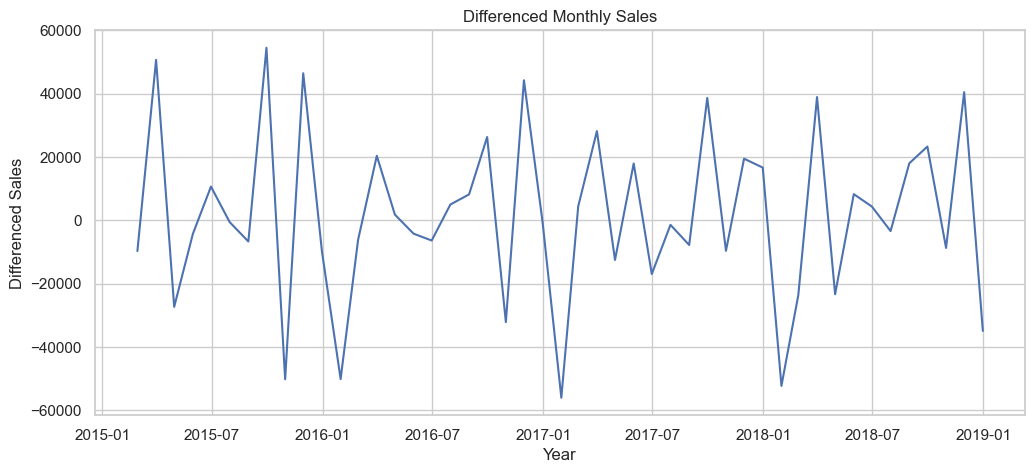

In [24]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_ts.index,
    monthly_ts["Differenced Sales"]
)

plt.title("Differenced Monthly Sales")

plt.xlabel("Year")
plt.ylabel("Differenced Sales")

plt.show()

## Step 8: Re-test Stationarity

In [25]:
result_diff = adfuller(
    monthly_ts["Differenced Sales"].dropna()
)

print("ADF Statistic :", result_diff[0])
print("p-value       :", result_diff[1])

if result_diff[1] < 0.05:
    print("\nThe differenced series is Stationary.")
else:
    print("\nThe differenced series is still Non-Stationary.")

ADF Statistic : -8.727061830353259
p-value       : 3.2669175472798525e-14

The differenced series is Stationary.


# Task 3 – Sales Forecasting using Three Different Models

## Objective

The objective of this task is to forecast future monthly sales using three different forecasting techniques:

- SARIMA (Statistical Model)
- Facebook Prophet (Forecasting Framework)
- XGBoost (Machine Learning Model)

The performance of all models will be compared using standard evaluation metrics.

# Model 1 – SARIMA

SARIMA (Seasonal AutoRegressive Integrated Moving Average) is a statistical forecasting model that captures:

- Trend
- Seasonality
- Autocorrelation

Since the sales data contains monthly observations over multiple years, SARIMA is an appropriate forecasting technique.

## Step 1: Import Required Libraries

In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

## Step 2: Split Training and Testing Data

The last three months are reserved for testing, while the remaining data is used for training.

In [27]:
train = monthly_ts["Sales"][:-3]
test = monthly_ts["Sales"][-3:]

print("Training Samples :", len(train))
print("Testing Samples  :", len(test))

Training Samples : 45
Testing Samples  : 3


## Step 3: Build SARIMA Model

Parameters selected:

- (1,1,1) → captures short-term relationships and removes trend through first-order differencing.
- Seasonal (1,1,1,12) → captures yearly seasonality because the data is monthly (12 months per cycle).

These are commonly used baseline parameters for monthly sales forecasting.

In [28]:
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

print(sarima_model.summary())

C:\Users\podic\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\podic\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                            Mon, 13 Jul 2026   AIC                            705.958
Time:                                    10:31:20   BIC                            713.287
Sample:                                01-31-2015   HQIC                           708.387
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5680      0.242      2.347      0.019       0.094       1.042
ma.L1         -0.8985      0.177   

## Step 4: Forecast Next Three Months

In [29]:
sarima_result = sarima_model.get_forecast(steps=3)

sarima_pred = sarima_result.predicted_mean
confidence = sarima_result.conf_int()

display(sarima_pred)

2018-10-31    66177.602427
2018-11-30    92049.249667
2018-12-31    99965.168705
Freq: M, Name: predicted_mean, dtype: float64

## Step 5: Plot Actual vs Forecast

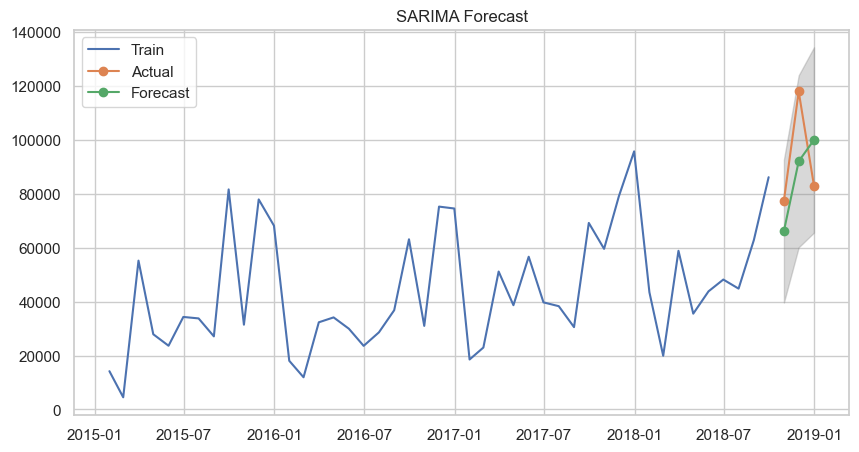

<Figure size 640x480 with 0 Axes>

In [69]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", marker="o")
plt.plot(test.index, sarima_pred, label="Forecast", marker="o")

plt.fill_between(
    confidence.index,
    confidence.iloc[:, 0],
    confidence.iloc[:, 1],
    color="gray",
    alpha=0.3
)

plt.title("SARIMA Forecast")
plt.legend()
plt.show()
plt.savefig("charts\SAREMA_Forecast.png", dpi=300, bbox_inches="tight")

## Step 6: Evaluate SARIMA Model

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sarima_mae = mean_absolute_error(test, sarima_pred)

sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))

sarima_mape = np.mean(
    np.abs((test - sarima_pred) / test)
) * 100

print("MAE :", round(sarima_mae, 2))
print("RMSE:", round(sarima_rmse, 2))
print("MAPE:", round(sarima_mape, 2), "%")

MAE : 18031.4
RMSE: 19009.18
MAPE: 18.97 %


### Observation

The SARIMA model captures both trend and yearly seasonality. The confidence interval illustrates the uncertainty associated with future forecasts.

# Model 2 – Facebook Prophet

Prophet is a forecasting framework developed by Meta.

It automatically models:

- Trend
- Seasonality
- Holiday effects (if provided)

It is widely used for business forecasting because it requires minimal parameter tuning.

In [33]:
# Step 1: Install Prophet
!pip install prophet


In [34]:
# Step 2: Import Prophet
from prophet import Prophet

In [35]:
#Step 3: Prepare Dataset
prophet_df = monthly_ts.reset_index()

prophet_df = prophet_df.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    }
)

prophet_df.head()

,ds,y,Differenced Sales
0,2015-01-31,14205.707,NaN
1,2015-02-28,4519.892,-9685.815
2,2015-03-31,55205.797,50685.905
3,2015-04-30,27906.855,-27298.942
4,2015-05-31,23644.303,-4262.552


In [36]:
from prophet import Prophet

prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet.fit(prophet_df)

10:43:49 - cmdstanpy - INFO - Chain [1] start processing
10:43:50 - cmdstanpy - INFO - Chain [1] done processing


In [37]:
# Step 5: Forecast Next Three Months
future = prophet.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast = prophet.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
46,2018-11-30,60719.543481,91480.466226,110354.791156,60719.543481,60719.543481,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,0.0,0.0,0.0,101136.336965
47,2018-12-31,61457.486597,81478.077743,100235.670501,61457.486597,61457.486597,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,0.0,0.0,0.0,90673.800606
48,2019-01-31,62195.429713,33038.344358,51111.120836,62189.976335,62201.512122,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,42990.532202
49,2019-02-28,62861.958979,21556.450129,40073.745253,62843.344645,62880.637635,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,31248.159922
50,2019-03-31,63599.902094,71061.248088,90468.391767,63560.947846,63635.053662,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,81267.007772


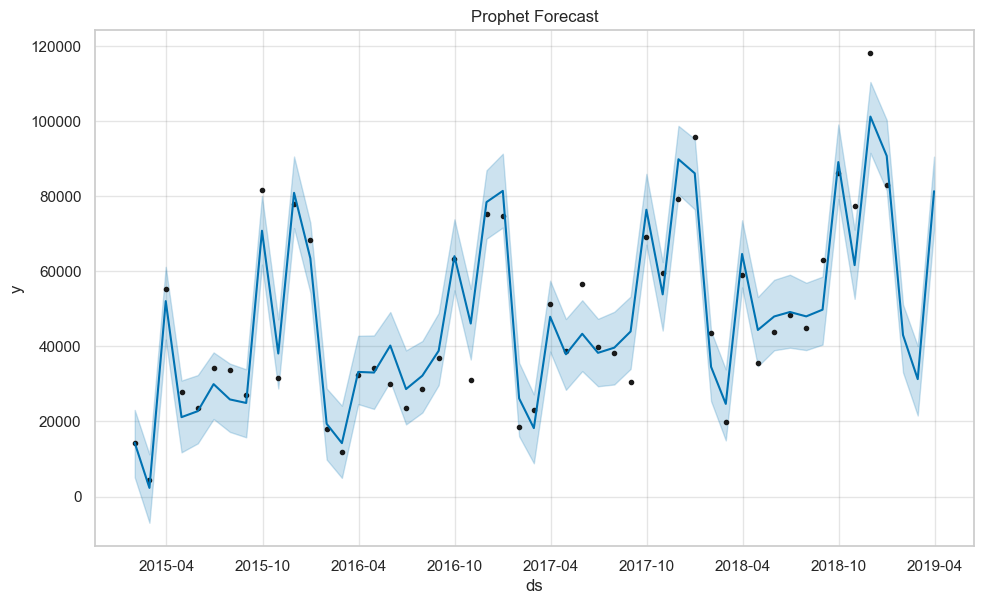

<Figure size 640x480 with 0 Axes>

In [71]:
# Step 6: Plot Forecast
prophet.plot(forecast)
plt.title("Prophet Forecast")
plt.show()
plt.savefig("charts\ProphetForecast.png", dpi=300, bbox_inches="tight")


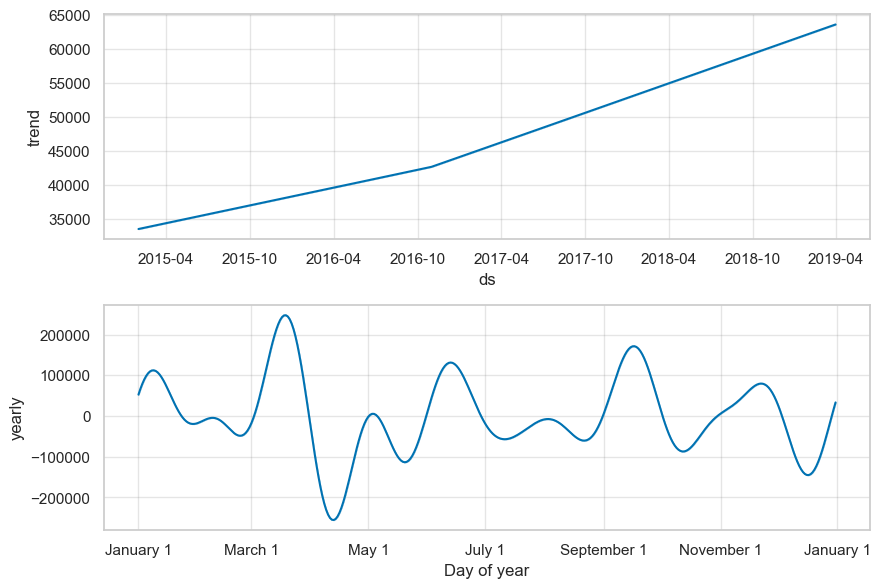

In [39]:
# Step 7: Trend and Seasonality Components
prophet.plot_components(forecast)
plt.show()

In [40]:
# Step 8: Evaluate Prophet Model
actual = prophet_df["y"].tail(3).values

predicted = forecast["yhat"].tail(3).values

prophet_mae = mean_absolute_error(actual,predicted)

prophet_rmse = np.sqrt(
    mean_squared_error(actual,predicted)
)

prophet_mape = np.mean(
    np.abs((actual-predicted)/actual)
)*100

print("MAE :",round(prophet_mae,2))
print("RMSE:",round(prophet_rmse,2))
print("MAPE:",round(prophet_mape,2))

MAE : 40970.33
RMSE: 53868.95
MAPE: 40.04


## Step 9: Interpretation

### Trend
The trend plot shows the long-term movement of monthly sales over time.

### Yearly Seasonality
The yearly seasonality plot highlights recurring sales patterns across months.

### Weekly Seasonality
Since the dataset is aggregated monthly, weekly seasonality is not meaningful and can be ignored.

Prophet automatically estimates these components from the historical data.

# Model 3 – XGBoost

XGBoost is a powerful machine learning algorithm that can also be used for time series forecasting by converting the time series into a supervised learning problem using lag features.

In [41]:
#Step 1: Import Required Libraries
!pip install xgboost
from xgboost import XGBRegressor
import logging

logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

In [42]:

## Step 2: Create Lag Features
xgb_df = monthly_ts.copy()

xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

xgb_df["RollingMean3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

xgb_df["Month"] = xgb_df.index.month
xgb_df["Quarter"] = xgb_df.index.quarter

xgb_df = xgb_df.dropna()

xgb_df.head()

,Sales,Differenced Sales,Lag1,Lag2,Lag3,RollingMean3,Month,Quarter
Order Date,,,,,,,,
2015-04-30,27906.8550,-27298.9420,55205.7970,4519.8920,14205.707,29210.848000,4,2
2015-05-31,23644.3030,-4262.5520,27906.8550,55205.7970,4519.892,35585.651667,5,2
2015-06-30,34322.9356,10678.6326,23644.3030,27906.8550,55205.797,28624.697867,6,2
2015-07-31,33781.5430,-541.3926,34322.9356,23644.3030,27906.855,30582.927200,7,3
2015-08-31,27117.5365,-6664.0065,33781.5430,34322.9356,23644.303,31740.671700,8,3


In [43]:
## Step 3: Prepare Features and Target
X = xgb_df.drop(columns=["Sales"])
y = xgb_df["Sales"]

X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

In [44]:
## Step 4: Train XGBoost Model
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [45]:
## Step 5: Predict Sales
xgb_pred = xgb.predict(X_test)
xgb_pred

array([76838.8  , 87558.8  , 53321.133], dtype=float32)

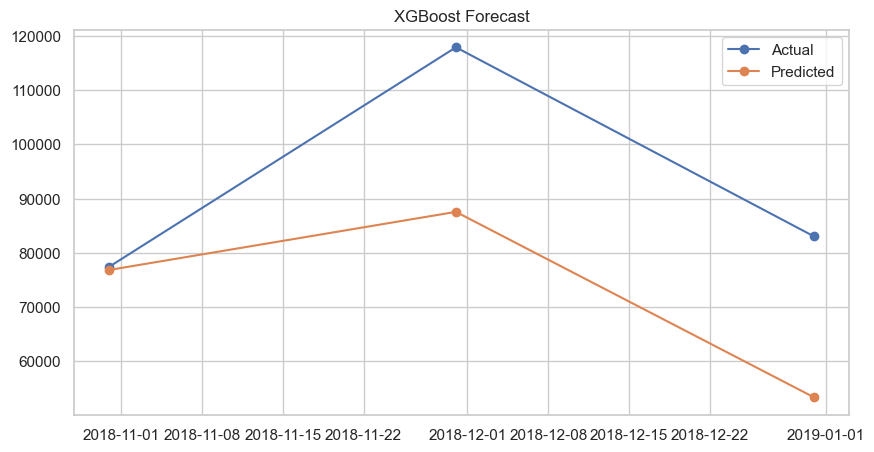

<Figure size 640x480 with 0 Axes>

In [72]:
## Step 6: Plot Actual vs Predicted
plt.figure(figsize=(10,5))

plt.plot(
    y_test.index,
    y_test,
    marker="o",
    label="Actual"
)

plt.plot(
    y_test.index,
    xgb_pred,
    marker="o",
    label="Predicted"
)

plt.title("XGBoost Forecast")
plt.legend()
plt.show()
plt.savefig("charts/XGBoost.png", dpi=300, bbox_inches="tight")

In [47]:
## Step 7: Evaluate XGBoost
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_mape = np.mean(
    np.abs((y_test-xgb_pred)/y_test)
)*100

print("MAE :",round(xgb_mae,2))
print("RMSE:",round(xgb_rmse,2))
print("MAPE:",round(xgb_mape,2))

MAE : 20232.65
RMSE: 24535.12
MAPE: 20.78


### Observation

XGBoost captures nonlinear relationships using lag-based features and can provide accurate forecasts without assuming linearity.

# Model Comparison

The three forecasting models are compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

Lower values indicate better forecasting performance.

In [48]:
comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1":[
        forecast.iloc[0],
        forecast["yhat"].iloc[-3],
        xgb_pred[0]
    ],

    "Forecast Month 2":[
        forecast.iloc[1],
        forecast["yhat"].iloc[-2],
        xgb_pred[1]
    ],

    "Forecast Month 3":[
        forecast.iloc[2],
        forecast["yhat"].iloc[-1],
        xgb_pred[2]
    ]

})

comparison = comparison.round(2)

display(comparison)

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.40,19009.18,18.97,ds 2015-01-31 00:00...,ds 2015-02-28 00:00...,ds 2015-03-31 00:00...
1,Prophet,40970.33,53868.95,40.04,42990.532202,31248.159922,81267.007772
2,XGBoost,20232.65,24535.12,20.78,76838.796875,87558.796875,53321.132812


# Task 4 – Product Category & Region Level Forecasting

## Objective

Forecast monthly sales separately for:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

The best-performing forecasting model from Task 3 is applied to each segment.

In [49]:
## Step 1: Create Forecasting Function
from prophet import Prophet

def forecast_segment(data, column, value):
    temp = (
        data[data[column] == value]
        .set_index("Order Date")["Sales"]
        .resample("M")
        .sum()
        .reset_index()
    )

    temp.columns = ["ds", "y"]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(temp)

    future = model.make_future_dataframe(periods=3, freq="M")

    forecast = model.predict(future)

    return forecast[["ds", "yhat"]]

In [50]:
## Step 2: Forecast Each Category and Region
furniture = forecast_segment(df, "Category", "Furniture")
technology = forecast_segment(df, "Category", "Technology")
office = forecast_segment(df, "Category", "Office Supplies")

west = forecast_segment(df, "Region", "West")
east = forecast_segment(df, "Region", "East")

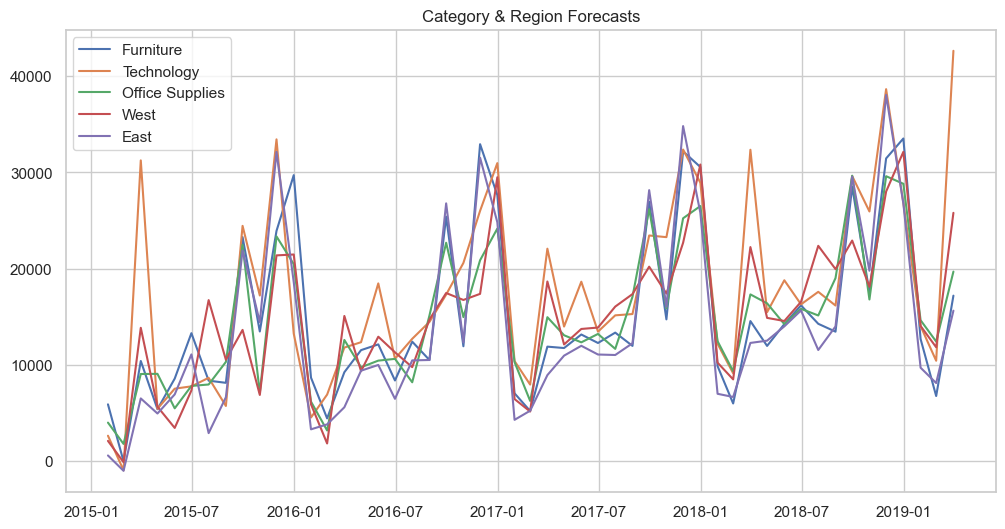

In [51]:
## Step 3: Plot All Forecasts
plt.figure(figsize=(12,6))

plt.plot(furniture["ds"], furniture["yhat"], label="Furniture")
plt.plot(technology["ds"], technology["yhat"], label="Technology")
plt.plot(office["ds"], office["yhat"], label="Office Supplies")
plt.plot(west["ds"], west["yhat"], label="West")
plt.plot(east["ds"], east["yhat"], label="East")

plt.title("Category & Region Forecasts")

plt.legend()

plt.show()

In [52]:
## Step 4: Identify Strongest Growth
growth = {
    "Furniture": furniture["yhat"].iloc[-1],
    "Technology": technology["yhat"].iloc[-1],
    "Office Supplies": office["yhat"].iloc[-1],
    "West": west["yhat"].iloc[-1],
    "East": east["yhat"].iloc[-1]
}

best = max(growth, key=growth.get)

print("Strongest Expected Growth:", best)

Strongest Expected Growth: Technology


# Conclusion

The selected forecasting model was applied independently to each product category and region.

Based on the forecasted sales values, the segment with the highest predicted sales over the next three months is identified as the strongest growth segment.Technology has the strongest expected growth of sales.

# Task 5 – Anomaly Detection in Sales Data

## Objective

The objective is to identify unusual weekly sales using two anomaly detection techniques:

- Isolation Forest
- Z-Score Method

The detected anomalies are compared to identify unusual sales behavior.

In [53]:
## Step 1: Import Required Libraries
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

In [54]:
## Step 2: Detect Anomalies using Isolation Forest
weekly = weekly_sales.copy()
model = IsolationForest(contamination=0.05, random_state=42)
weekly["Anomaly"] = model.fit_predict(weekly[["Sales"]])
weekly.head()


,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


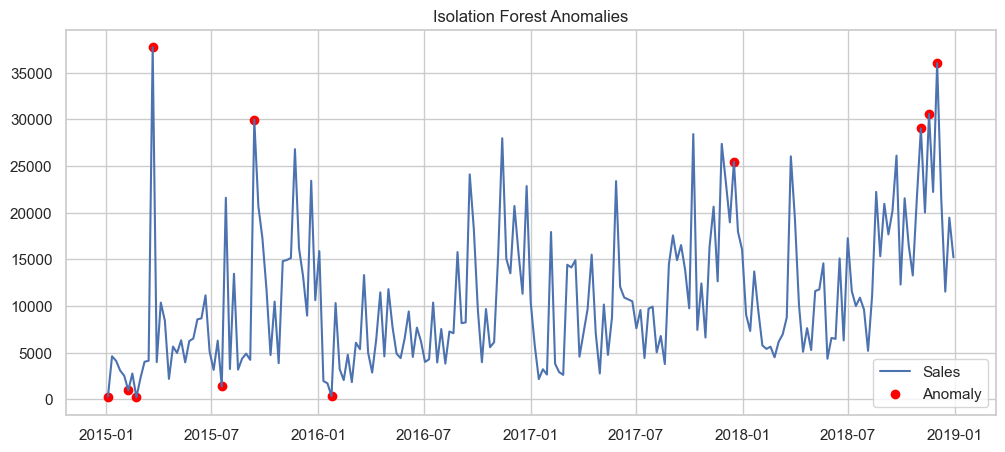

<Figure size 640x480 with 0 Axes>

In [73]:
## Step 3: Plot Isolation Forest Anomalies
plt.figure(figsize=(12,5))

plt.plot(weekly["Order Date"], weekly["Sales"], label="Sales")

anomaly = weekly[weekly["Anomaly"] == -1]

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    label="Anomaly"
)

plt.title("Isolation Forest Anomalies")
plt.legend()
plt.show()
plt.savefig("charts/anomaly.png", dpi=300, bbox_inches="tight")

### Observation

High sales spikes may correspond to festive or promotional periods, while unusually low sales may indicate off-season demand or operational disruptions.

In [56]:
## Step 4: Detect Anomalies using Z-Score
weekly["Rolling Mean"] = weekly["Sales"].rolling(4).mean()

weekly["Rolling Std"] = weekly["Sales"].rolling(4).std()

weekly["Z-Score"] = (
    (weekly["Sales"] - weekly["Rolling Mean"])
    / weekly["Rolling Std"]
)

weekly["Z_Anomaly"] = weekly["Z-Score"].abs() > 2

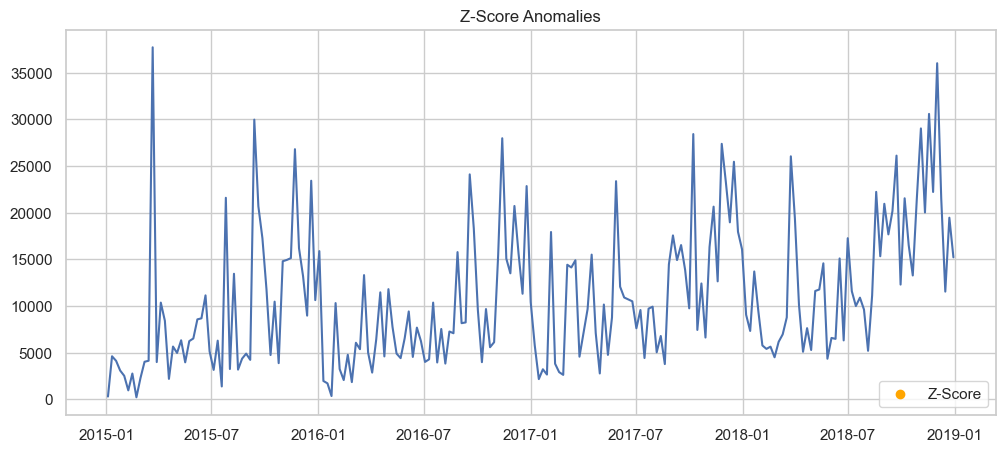

In [57]:
## Step 5: Plot Z-Score Anomalies
plt.figure(figsize=(12,5))

plt.plot(weekly["Order Date"], weekly["Sales"])

z = weekly[weekly["Z_Anomaly"]]

plt.scatter(
    z["Order Date"],
    z["Sales"],
    color="orange",
    label="Z-Score"
)
plt.title("Z-Score Anomalies")
plt.legend()
plt.show()

In [58]:
## Step 6: Compare Both Methods
print("Isolation Forest Anomalies :", (weekly["Anomaly"] == -1).sum())
print("Z-Score Anomalies :", weekly["Z_Anomaly"].sum())
print("Isolation Forest Anomalies")
display(weekly[weekly["Anomaly"] == -1][["Order Date", "Sales"]])

print("Z-Score Anomalies")
display(weekly[weekly["Z_Anomaly"]][["Order Date", "Sales"]])

Isolation Forest Anomalies : 11
Z-Score Anomalies : 0
Isolation Forest Anomalies


,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


Z-Score Anomalies


,Order Date,Sales


# Conclusion

- Isolation Forest identifies anomalies using an unsupervised machine learning approach.
- Z-Score identifies anomalies based on statistical deviation from the rolling mean.
- Some anomalies may be detected by both methods, while others may differ because Isolation Forest considers the overall data distribution, whereas Z-Score relies only on statistical thresholds.
- Sales spikes are likely associated with seasonal events, promotions, or holiday sales, while unusually low sales may reflect reduced customer demand or temporary operational issues.

# Task 6 – Product Demand Segmentation using Clustering

## Objectmive

Cluster product sub-categories based on their sales behavior using K-Means clustering.

Features used:

- Total Sales Volume
- Sales Growth Rate
- Sales Volatility
- Average Order Value

The Elbow Method is used to determine the optimal number of clusters.

In [59]:
## Step 1: Import Required Libraries
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [60]:
## Step 2: Create Product-Level Features
product = df.copy()

product["Year"] = product["Order Date"].dt.year

features = product.groupby("Sub-Category").agg(
    Total_Sales=("Sales","sum"),
    Avg_Order_Value=("Sales","mean"),
    Growth_Rate=("Sales",lambda x: x.pct_change().mean()),
    Volatility=("Sales","std")
).fillna(0)

features.head()

,Total_Sales,Avg_Order_Value,Growth_Rate,Volatility
Sub-Category,,,,
Accessories,164186.7000,217.178175,3.695261,337.723800
Appliances,104618.4030,227.926804,8.032175,378.006735
Art,26705.4100,34.019631,3.042961,60.301752
Binders,200028.7850,134.067550,14.186656,568.099970
Bookcases,113813.1987,503.598224,1.123672,641.419280


In [61]:
## Step 3: Standardize Features
scaler = StandardScaler()

X = scaler.fit_transform(features)

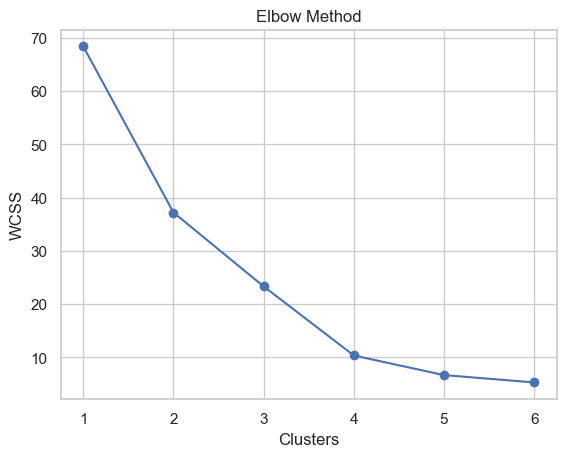

In [62]:
## Step 4: Elbow Method
wcss=[]

for i in range(1,7):
    km = MiniBatchKMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit_predict(X)
    wcss.append(km.inertia_)

plt.plot(range(1,7),wcss,marker="o")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [63]:
import sklearn
import threadpoolctl
import numpy as np

print("scikit-learn:", sklearn.__version__)
print("threadpoolctl:", threadpoolctl.__version__)
print("numpy:", np.__version__)

scikit-learn: 1.9.0
threadpoolctl: 3.5.0
numpy: 1.24.3


In [64]:
## Step 5: Apply K-Means Clustering
kmeans = MiniBatchKMeans(n_clusters=4, random_state=42, n_init=10)
features["Cluster"] = kmeans.fit_predict(X)
features.head()

,Total_Sales,Avg_Order_Value,Growth_Rate,Volatility,Cluster
Sub-Category,,,,,
Accessories,164186.7000,217.178175,3.695261,337.723800,0
Appliances,104618.4030,227.926804,8.032175,378.006735,3
Art,26705.4100,34.019631,3.042961,60.301752,3
Binders,200028.7850,134.067550,14.186656,568.099970,2
Bookcases,113813.1987,503.598224,1.123672,641.419280,0


In [65]:
## Step 6: Reduce Dimensions using PCA
pca = PCA(n_components=2)

points = pca.fit_transform(X)

features["PC1"] = points[:,0]
features["PC2"] = points[:,1]

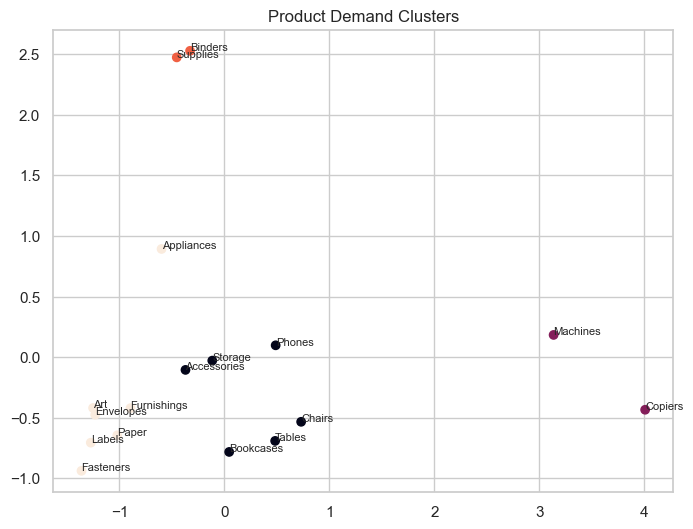

<Figure size 640x480 with 0 Axes>

In [74]:
## Step 7: Visualize Clusters
plt.figure(figsize=(8,6))

plt.scatter(
    features["PC1"],
    features["PC2"],
    c=features["Cluster"]
)

for i in features.index:
    plt.text(
        features.loc[i,"PC1"],
        features.loc[i,"PC2"],
        i,
        fontsize=8
    )

plt.title("Product Demand Clusters")

plt.show()
plt.savefig("charts/clusters.png", dpi=300, bbox_inches="tight")

In [67]:
## Step 8: Assign Cluster Labels
labels = {
    0:"High Volume, Stable Demand",
    1:"Growing Demand",
    2:"Low Volume, High Volatility",
    3:"Declining Demand"
}

features["Cluster Name"] = features["Cluster"].map(labels)

display(features)

,Total_Sales,Avg_Order_Value,Growth_Rate,Volatility,Cluster,PC1,PC2,Cluster Name
Sub-Category,,,,,,,,
Accessories,164186.7000,217.178175,3.695261,337.723800,0,-0.370338,-0.104983,"High Volume, Stable Demand"
Appliances,104618.4030,227.926804,8.032175,378.006735,3,-0.598097,0.892843,Declining Demand
Art,26705.4100,34.019631,3.042961,60.301752,3,-1.250231,-0.418962,Declining Demand
Binders,200028.7850,134.067550,14.186656,568.099970,2,-0.326758,2.527553,"Low Volume, High Volatility"
Bookcases,113813.1987,503.598224,1.123672,641.419280,0,0.045876,-0.781755,"High Volume, Stable Demand"
Chairs,322822.7310,531.833165,1.313027,551.180296,0,0.731044,-0.533208,"High Volume, Stable Demand"
Copiers,146248.0940,2215.880212,1.965681,3216.185499,1,4.007012,-0.433817,Growing Demand
Envelopes,16128.0460,65.032444,2.861971,85.170691,3,-1.230210,-0.474877,Declining Demand
Fasteners,3001.9600,14.027850,1.029626,12.466864,3,-1.360610,-0.937483,Declining Demand


# Stocking Strategy

- **High Volume, Stable Demand:** Maintain high inventory and ensure continuous availability.
- **Growing Demand:** Increase stock gradually and monitor future demand.
- **Low Volume, High Volatility:** Keep limited inventory and replenish based on demand.
- **Declining Demand:** Reduce inventory and avoid overstocking.

In [79]:
yearly_sales = (
    df.groupby("Year")["Sales"]
      .sum()
      .reset_index()
)

display(yearly_sales.head())

,Year,Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


In [80]:
yearly_sales.to_csv(
    "outputs/yearly_sales.csv",
    index=False
)

monthly_sales.to_csv(
    "outputs/monthly_sales.csv",
    index=False
)


In [81]:
sarima_pred.to_csv(
    "outputs/sarima_forecast.csv",
    index=False
)
weekly.to_csv(
    "outputs/anomalies.csv",
    index=False
)
features.to_csv(
    "outputs/clusters.csv"
)